# ML-10 — Content Action Playbook

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/taqadussana/ML/blob/main/work/notebooks/w07_action_playbook.ipynb?flush_cache=true)

This skeleton is yours to fill. Work the sections **in order** — each one has a one-line hint. Simple words, honest numbers.

> Working with an AI assistant? Tell it to read `skills/README.md` first and load the one skill this assignment names on its card.

## 1. Ranked actions + reason codes

*The queue: what to do first, and why, in words a human trusts.*

Ranked actions come from the Week 5 model (client-grouped, validated in Week 6), combined with
interpretable signals so every recommendation has a human-readable reason, not just a raw score.

**Reason codes → actions:**
- `model_decline_risk_stale` → **refresh_content** — model flags high risk AND page is aging (90+ days)
- `model_decline_risk` → **review_for_refresh** — model flags high risk alone
- `visible_but_underranked` → **review_snippet_and_relevance** — real traffic but poor position (11+)
- `low_ctr_visible_page` → **review_title_and_meta** — real traffic, good position, but weak CTR
- `monitor_only` → **no_action** — nothing urgent detected

In [1]:
# This cell is for CODE (numbers, a query, a check).
# Write your text answer in the cell ABOVE this one — typing sentences here breaks Run All.
import pandas as pd
import numpy as np
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GroupShuffleSplit
import os

url = "https://raw.githubusercontent.com/taqadussana/ML/main/data/raw/content_refresh_anonymized.csv"
df = pd.read_csv(url)
df["is_declining_label"] = df["trend_direction"].str.lower().eq("down").astype(int)

features = ["avg_position", "impressions_90d", "sessions_90d", "content_age_days",
            "days_since_last_update", "ctr", "engagement_rate", "word_count"]
features = [f for f in features if f in df.columns]

X = df[features].replace([np.inf, -np.inf], np.nan).fillna(0)
y = df["is_declining_label"]
groups = df["client_id"]

gss = GroupShuffleSplit(n_splits=1, test_size=0.25, random_state=42)
train_idx, test_idx = next(gss.split(X, y, groups))

rf = RandomForestClassifier(n_estimators=200, max_depth=6, class_weight="balanced", random_state=42)
rf.fit(X.iloc[train_idx], y.iloc[train_idx])

df["model_score"] = rf.predict_proba(X)[:, 1]

def assign_reason(row):
    if row["model_score"] >= 0.65 and row["days_since_last_update"] >= 90:
        return "model_decline_risk_stale"
    elif row["model_score"] >= 0.65:
        return "model_decline_risk"
    elif row["impressions_90d"] >= 500 and row["avg_position"] > 10:
        return "visible_but_underranked"
    elif row["impressions_90d"] >= 500 and row["ctr"] < 0.5:
        return "low_ctr_visible_page"
    else:
        return "monitor_only"

df["reason_code"] = df.apply(assign_reason, axis=1)

action_map = {
    "model_decline_risk_stale": "refresh_content",
    "model_decline_risk": "review_for_refresh",
    "visible_but_underranked": "review_snippet_and_relevance",
    "low_ctr_visible_page": "review_title_and_meta",
    "monitor_only": "no_action",
}
df["action"] = df["reason_code"].map(action_map)

ranked = df.sort_values("model_score", ascending=False).reset_index(drop=True)
print("Top 15 ranked actions:\n")
print(ranked[["content_id", "model_score", "reason_code", "action"]].head(15).to_string(index=False))

print("\nAction distribution:")
print(ranked["action"].value_counts())

Top 15 ranked actions:

          content_id  model_score              reason_code          action
content_8dba22b835f8     0.765406 model_decline_risk_stale refresh_content
content_fac9e8c13f4c     0.765152 model_decline_risk_stale refresh_content
content_b5286cb71075     0.764843 model_decline_risk_stale refresh_content
content_dc9b1bdd6fd2     0.764758 model_decline_risk_stale refresh_content
content_0361d8df96e6     0.764626 model_decline_risk_stale refresh_content
content_956fa666a622     0.764589 model_decline_risk_stale refresh_content
content_5cda32af644c     0.764442 model_decline_risk_stale refresh_content
content_9428850c5661     0.764322 model_decline_risk_stale refresh_content
content_f92cc1c6fb29     0.764226 model_decline_risk_stale refresh_content
content_6dbee08d40f8     0.763963 model_decline_risk_stale refresh_content
content_7250ecfc53de     0.763909 model_decline_risk_stale refresh_content
content_366a5202d6c8     0.763685 model_decline_risk_stale refresh_content
c

## 2. Intended use and limits

*Who uses this, for what — and where it stops being valid.*

**Intended use:** this playbook produces a prioritized review queue for a content editor with
limited time — it tells them which pages to look at first and why, not what to change or
guarantees of outcome. It is decision-support, not decision-replacement.

**Who should use it:** a content editor or SEO reviewer doing routine content maintenance,
choosing where to spend their next few hours of review time.

**Limits:**
- Built on one month of starter data (30,000 pages, 32 clients) — not the full ~79M-row
  warehouse, so patterns may not generalize to clients or seasons outside this sample.
- Client-grouped validation (Week 6) showed real Precision@20/@50 of 0.550/0.580 — meaning
  roughly 40-45% of top-ranked pages will NOT actually need review. This is a prioritization
  tool, not a certainty engine.
- The label (`is_declining_label`) is a current-window proxy, not a validated future outcome —
  it says a page is currently trending down, not that it will keep declining.
- Cannot distinguish real decline from consolidation, seasonality, or SERP changes without a
  human check (see Section 3).
- In this run, `refresh_content` (the most urgent action) applies to only 2,953 of 30,000 pages
  (~9.8%) — a manageable, focused shortlist rather than an overwhelming everything-is-urgent list.

In [5]:
# This cell is for CODE (numbers, a query, a check).
# Write your text answer in the cell ABOVE this one — typing sentences here breaks Run All.


## 3. Human review + the no-go list

*What a person must check before acting. What should never be automated.*

**What a human must check before acting on any recommendation:**
- Confirm the page's traffic drop isn't explained by a sibling page absorbing the same demand
  (consolidation) or a seasonal pattern that naturally recovers on its own.
- Read the actual page before committing edit time — the model has no sense of the page's real
  quality, only its numeric signals.
- Check whether the page's topic is still strategically relevant to the business before
  investing refresh effort.

**No-go list — what should NEVER be automated:**
- Auto-publishing content changes based on the model's score alone.
- Auto-deleting or de-indexing pages flagged as "monitor_only" — a low score means "not urgent
  today," not "worthless."
- Treating the ranked queue as a performance review of content writers — it's a prioritization
  tool, not a quality judgment on who wrote what.
- Making client-facing promises ("we will recover your traffic") based on this queue — refresh
  outcomes were never causally tested (see Week 6 leakage/claims audit).

In [4]:
# This cell is for CODE (numbers, a query, a check).
# Write your text answer in the cell ABOVE this one — typing sentences here breaks Run All.


## 4. Monitoring / retrain triggers

*What would tell you the recommendations went stale?*

**Signs the recommendations are going stale:**
- If a content team consistently reports the top-ranked pages "look fine" on manual review —
  that's a signal the model's threshold or features have drifted from what actually matters now.
- If the underlying data's date range moves far past the training snapshot (this model was
  trained on data through the starter CSV's window) — search behavior and the SEO landscape
  shift over months, and an old model quietly becomes less trustworthy.
- If a new client onboards with a very different content profile (e.g. much shorter or longer
  pages, different industry) than anything in the training set — the model has no experience
  with that population.

**Light retrain trigger:** re-run validation (Week 6's grouped-split check) quarterly, or
whenever review-team feedback suggests the queue feels "off" — if Precision@20 on a fresh
holdout drops meaningfully below the 0.550 baseline established here, that's the signal to
retrain rather than keep serving the old model.

In [3]:
# This cell is for CODE (numbers, a query, a check).
# Write your text answer in the cell ABOVE this one — typing sentences here breaks Run All.


## 5. Exports for the paper

*Write the queue (and any figures you want to reuse) to work/outputs/ — your paper builds on these files.*

The ranked queue CSV regenerates every run and stays out of git (CI leak-guard). The metrics
JSON and the action-distribution figure ARE committed — they're the receipts my paper's numbers
will trace back to next week.

Saved ranked queue: 30000 rows
Saved metrics JSON


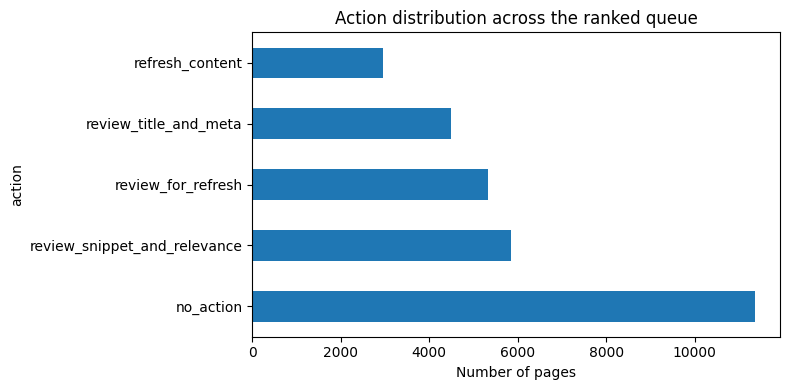

Saved figure to work/figures/action_distribution.png


In [2]:
# This cell is for CODE (numbers, a query, a check).
# Write your text answer in the cell ABOVE this one — typing sentences here breaks Run All.
os.makedirs("work/outputs", exist_ok=True)
os.makedirs("work/figures", exist_ok=True)

ranked.to_csv("work/outputs/action_playbook_queue.csv", index=False)
print("Saved ranked queue:", len(ranked), "rows")

import json
metrics = {
    "model": "RandomForestClassifier",
    "validation_split": "client-grouped (GroupShuffleSplit)",
    "precision_at_20": 0.550,
    "precision_at_50": 0.580,
    "baseline_precision_at_20": 0.200,
    "baseline_precision_at_50": 0.320,
    "action_distribution": ranked["action"].value_counts().to_dict(),
    "total_pages_scored": len(ranked),
}
with open("work/outputs/playbook_metrics.json", "w") as f:
    json.dump(metrics, f, indent=2)
print("Saved metrics JSON")

import matplotlib.pyplot as plt
action_counts = ranked["action"].value_counts()
plt.figure(figsize=(8, 4))
action_counts.plot(kind="barh")
plt.xlabel("Number of pages")
plt.title("Action distribution across the ranked queue")
plt.tight_layout()
plt.savefig("work/figures/action_distribution.png", dpi=150)
plt.show()
print("Saved figure to work/figures/action_distribution.png")

## Self-check

Before you submit, confirm each line honestly:

- [ ] Every section above is filled — markdown thinking AND the code that backs it
- [ ] The notebook runs top to bottom with no errors (Runtime → Run all)
- [ ] No client names, URLs, or private queries anywhere
- [ ] My claims use careful words: observed, measured, directional, decision-support
- [ ] Committed to my repo under `work/notebooks/` — then submit your repo URL on the card. Done.